In [7]:
import torch
import lightning.pytorch as pl
import numpy as np
import os
from typing import Optional, Union
from tqdm import tqdm

from models.vqvae import VQVAE

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

path = "test.memmap"
c = 5
w, h = 128, 64

data = np.memmap(path, mode="r", dtype=np.float32).reshape(-1, c, w, h)

mean: np.ndarray = np.array([5.4008180e+04, 2.7393976e+02, 2.3674958e-03, 2.7760931e+02, 6.2221546e+00], dtype=np.float32)
std: np.ndarray = np.array([3.3518201e+03, 1.5841744e+01, 2.4138752e-03, 2.1723423e+01, 3.4207888e+00], dtype=np.float32)

print(data.shape)

(9204, 5, 128, 64)


In [9]:
vqvae_path = 'weights/vqvae.ckpt'
vqvae = VQVAE.load_from_checkpoint(vqvae_path, in_channels=c).to(device)

In [10]:
latent_data = np.zeros((data.shape[0], 8, 16, 8), dtype=np.float32)

for i in tqdm(range(0, data.shape[0], 128)):

    batch = data[i:i+128]
    batch = (batch - mean[None, :, None, None]) / std[None, :, None, None]

    batch = torch.tensor(batch).to(device)

    with torch.no_grad():

        _, batch_latent, _ = vqvae(batch)

    latent_data[i:i+128] = batch_latent.cpu().numpy()

100%|██████████| 72/72 [00:14<00:00,  4.83it/s]


(9204, 8, 16, 8)


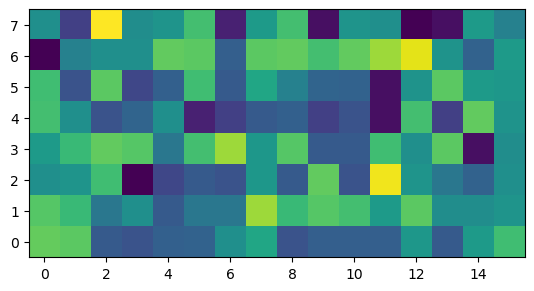

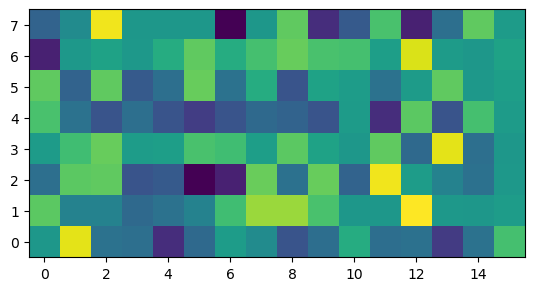

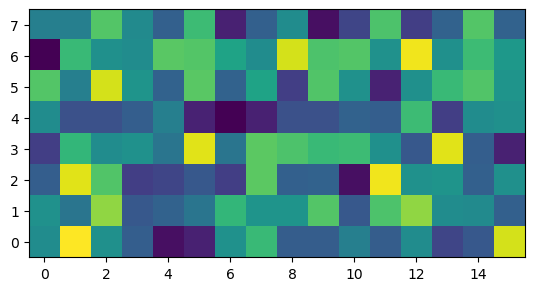

In [11]:
print(latent_data.shape)

from matplotlib import pyplot as plt

plt.imshow(latent_data[0, 0].T, origin='lower')
plt.show()

plt.imshow(latent_data[1, 0].T, origin='lower')
plt.show()

plt.imshow(latent_data[2, 0].T, origin='lower')
plt.show()

In [12]:
# save latent data
latent_path = "latent_test2.npy"
np.save(latent_path, latent_data)